# Notebook 5 — SOLUTION

## Short version

**Within every session, firing rate goes DOWN as pupil goes up.** The positive
pooled slope is **Simpson's paradox**: the sessions differ both in their average
pupil and in their baseline firing rate, and higher-arousal sessions happen to
have higher baseline rates. Pooling mixes this *between-session* trend with the
*within-session* relationship, and the between-session trend wins -- flipping the
sign. The pooled correlation answers a different question ("do high-arousal
*sessions* fire more?") than the one we care about ("does arousal drive firing
*within* a session?").


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


In [2]:
d = np.load('data/data.npz')
pupil = d['pupil']                 # arousal proxy, per trial (0-1)
firing_rate = d['firing_rate']     # spikes/s, per trial
session_id = d['session_id']       # which session each trial came from
n_sessions = session_id.max() + 1
print(f'{len(pupil)} trials from {n_sessions} sessions')


420 trials from 7 sessions


## Evidence 1 — Color the same scatter by session

The pooled cloud is made of several tilted sub-clouds, one per session. Each
slopes *down*; they are stacked up-and-to-the-right, which is what creates the
illusory positive pooled slope.


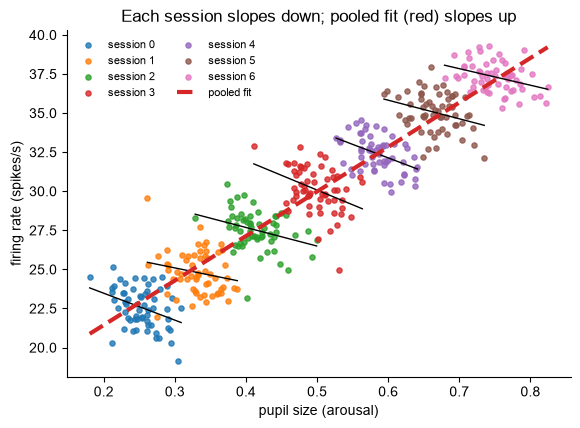

In [3]:
slope, intercept = np.polyfit(pupil, firing_rate, 1)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for s in range(n_sessions):
    m = session_id == s
    ax.scatter(pupil[m], firing_rate[m], s=14, alpha=0.8, label=f'session {s}')
    sl, ic = np.polyfit(pupil[m], firing_rate[m], 1)      # within-session fit
    xs = np.array([pupil[m].min(), pupil[m].max()])
    ax.plot(xs, ic + sl * xs, color='k', lw=1)
xs = np.array([pupil.min(), pupil.max()])
ax.plot(xs, intercept + slope * xs, color='tab:red', lw=3, ls='--', label='pooled fit')
ax.set_xlabel('pupil size (arousal)'); ax.set_ylabel('firing rate (spikes/s)')
ax.set_title('Each session slopes down; pooled fit (red) slopes up')
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.show()


## Evidence 2 — Within-session slopes vs. the pooled slope

Every session's slope is negative; only the pooled slope is positive.


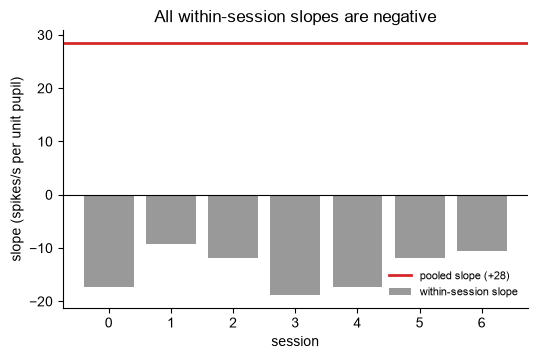

mean within-session slope: -13.9   pooled slope: +28.5


In [4]:
within = np.array([np.polyfit(pupil[session_id == s], firing_rate[session_id == s], 1)[0]
                   for s in range(n_sessions)])

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(range(n_sessions), within, color='0.6', label='within-session slope')
ax.axhline(slope, color='tab:red', lw=2, label=f'pooled slope ({slope:+.0f})')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('session'); ax.set_ylabel('slope (spikes/s per unit pupil)')
ax.set_title('All within-session slopes are negative')
ax.legend(frameon=False, fontsize=8)
plt.show()
print(f'mean within-session slope: {within.mean():+.1f}   pooled slope: {slope:+.1f}')


## Evidence 3 — The fix: analyze the within-session relationship

Remove each session's mean from both variables (so only within-session variation
remains), then pool. Equivalently, fit a model with a per-session intercept (a
mixed / within-subject model). The relationship is negative, as it truly is.


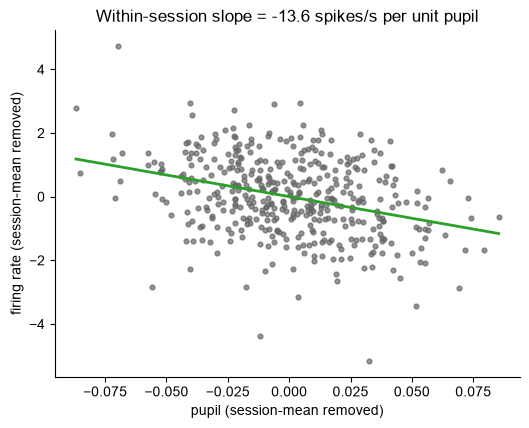

In [5]:
pupil_c = pupil.copy(); firing_c = firing_rate.copy()
for s in range(n_sessions):                    # subtract each session's means
    m = session_id == s
    pupil_c[m] -= pupil[m].mean()
    firing_c[m] -= firing_rate[m].mean()
slope_within, ic_within = np.polyfit(pupil_c, firing_c, 1)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pupil_c, firing_c, s=12, color='0.4', alpha=0.7)
xs = np.array([pupil_c.min(), pupil_c.max()])
ax.plot(xs, ic_within + slope_within * xs, color='tab:green', lw=2)
ax.set_xlabel('pupil (session-mean removed)'); ax.set_ylabel('firing rate (session-mean removed)')
ax.set_title(f'Within-session slope = {slope_within:+.1f} spikes/s per unit pupil')
plt.show()


## Ground truth


In [6]:
gt = np.load('data/ground_truth.npz', allow_pickle=True)
print('true within-session slope:', float(gt['within_slope']), 'spikes/s per unit pupil')
print('note:', str(gt['note']))


true within-session slope: -12.0 spikes/s per unit pupil
note: true within-session slope is NEGATIVE; the positive pooled slope is a between-session (Simpson's) artifact


## The lesson

- **A relationship pooled across groups can reverse the relationship within each
  group (Simpson's paradox).** It happens whenever the grouping variable
  (session, animal, subject) is related to *both* variables.
- **Decide which question you are asking.** "Do high-arousal sessions fire more?"
  (between-session) and "does arousal drive firing within a session?"
  (within-session) are different questions with, here, opposite answers. The
  pooled fit silently answers the first.
- **Respect the grouping structure.** Analyze within group (center by group, or
  fit a mixed-effects model with per-group intercepts) rather than pooling
  trials as if they were independent and exchangeable.
